# 6CS012 – Final Portfolio Assessment 2026
## Part III: Language Task — Sentiment Analysis of Movie Reviews using RNN, LSTM, and Word2Vec
**Herald College Kathmandu | University of Wolverhampton**

---
**Dataset:** IMDb Movie Review Dataset  
**Task:** Binary Sentiment Classification (Positive / Negative)  
**Models:** Simple RNN · LSTM · LSTM + GloVe Word2Vec  

---

## 0. Install Dependencies
> Run this cell first, then **Runtime → Restart session**, then run all remaining cells.

In [ ]:
!pip install gensim -q
!pip install wordcloud -q
!pip install gradio -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 74.7 MB/s eta 0:00:00


## 1. Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time
import warnings
from collections import Counter
warnings.filterwarnings('ignore')

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

# Sklearn
from sklearn.metrics import (
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay, accuracy_score,
    precision_score, recall_score, f1_score
)

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Gensim
import gensim.downloader as api

# NLTK downloads
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)

print('TensorFlow version :', tf.__version__)
print('GPU available      :', tf.config.list_physical_devices('GPU'))
print('All libraries imported successfully!')

TensorFlow version : 2.20.0
GPU available      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
All libraries imported successfully!


## 2. Load Dataset

In [ ]:
from google.colab import files
import zipfile, os

# Upload the zip file
uploaded = files.upload()

# Extract zip
zip_name = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall('.')

# Show extracted CSV paths
print('Extracted CSV files:')
for root, dirs, filenames in os.walk('.'):
    for f in filenames:
        if f.endswith('.csv') and 'movie' in f.lower():
            print(os.path.join(root, f))

Saving 5. Movie Review Dataset-20260502T104427Z-3-001.zip to 5. Movie Review Dataset-20260502T104427Z-3-001.zip
Extracted CSV files:
./5. Movie Review Dataset/train_movie_review.csv
./5. Movie Review Dataset/val_movie_review.csv
./5. Movie Review Dataset/test_movie_review.csv


In [26]:
TRAIN_PATH = './5. Movie Review Dataset/train_movie_review.csv'
VAL_PATH   = './5. Movie Review Dataset/val_movie_review.csv'
TEST_PATH  = './5. Movie Review Dataset/test_movie_review.csv'

train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

# Drop unnamed index column if present
for df in [train_df, val_df, test_df]:
    if 'Unnamed: 0' in df.columns:
        df.drop(columns=['Unnamed: 0'], inplace=True)

print(f'Train : {train_df.shape}')
print(f'Val   : {val_df.shape}')
print(f'Test  : {test_df.shape}')
train_df.head(3)

Train : (35000, 2)
Val   : (5000, 2)
Test  : (10000, 2)


,review,sentiment
0,"Having avoided seeing the movie in the cinema,...",0
1,With this movie I was really hoping that the i...,0
2,Raymond Burr stars as an attorney caught up in...,0


## 3. Exploratory Data Analysis (EDA)

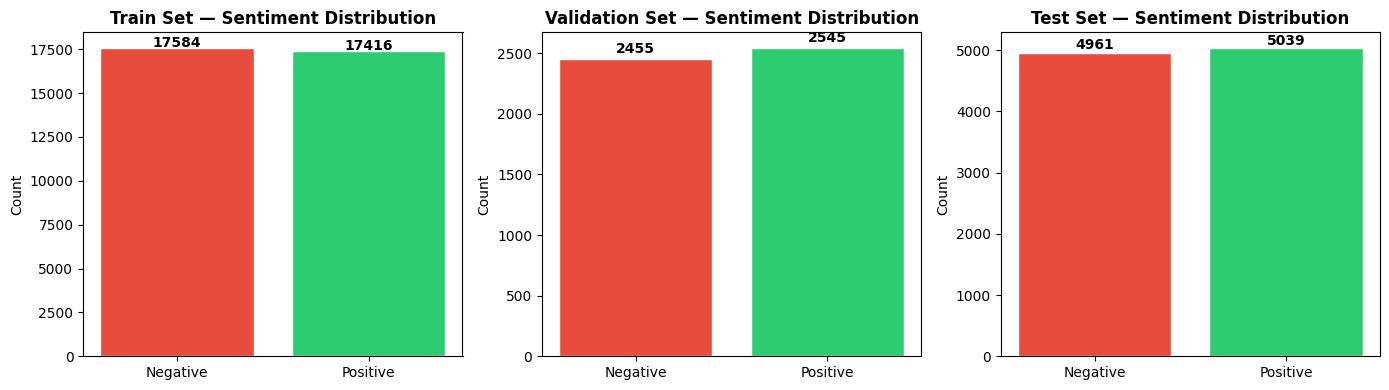

Observation: Dataset is well balanced — nearly equal positive and negative samples across all splits.


In [27]:
# ── 3.1 Class Distribution ────────────────────────────────────────────────────
labels = {0: 'Negative', 1: 'Positive'}
colors = ['#e74c3c', '#2ecc71']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (df, title) in zip(axes, [(train_df,'Train'),(val_df,'Validation'),(test_df,'Test')]):
    counts = df['sentiment'].value_counts().sort_index()
    ax.bar([labels[i] for i in counts.index], counts.values, color=colors, edgecolor='white')
    ax.set_title(f'{title} Set — Sentiment Distribution', fontweight='bold')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Observation: Dataset is well balanced — nearly equal positive and negative samples across all splits.')

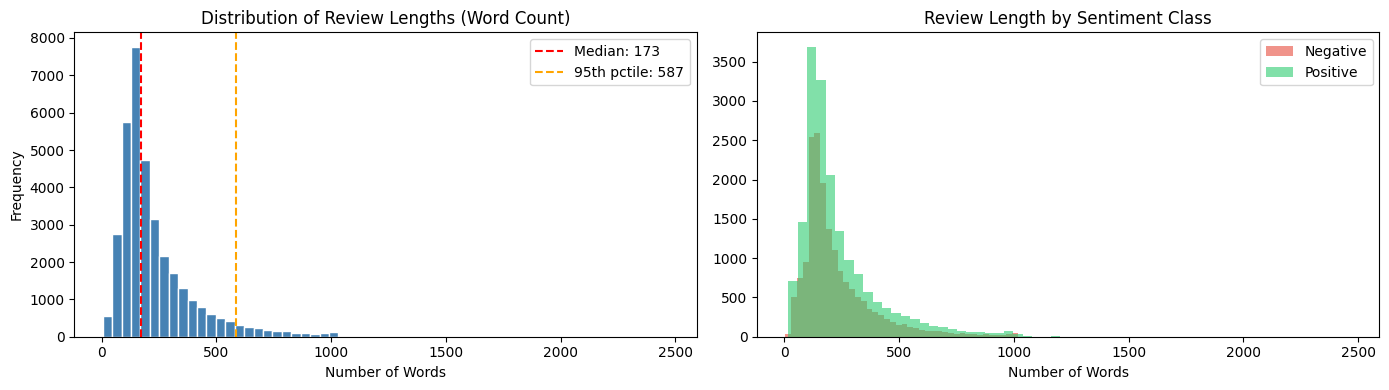

Mean length   : 230.7 words
Median length : 173.0 words
95th pctile   : 587 words
Observation: Both classes have similar length distributions — no length-based bias.


In [28]:
# ── 3.2 Review Length Distribution ───────────────────────────────────────────
train_df['review_length'] = train_df['review'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(train_df['review_length'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Review Lengths (Word Count)')
axes[0].set_xlabel('Number of Words')
axes[0].set_ylabel('Frequency')
axes[0].axvline(train_df['review_length'].median(), color='red',    linestyle='--',
                label=f"Median: {train_df['review_length'].median():.0f}")
axes[0].axvline(np.percentile(train_df['review_length'], 95), color='orange', linestyle='--',
                label=f"95th pctile: {np.percentile(train_df['review_length'], 95):.0f}")
axes[0].legend()

for label, color in [(0,'#e74c3c'),(1,'#2ecc71')]:
    axes[1].hist(train_df[train_df['sentiment']==label]['review_length'],
                 bins=60, alpha=0.6, color=color, label=labels[label])
axes[1].set_title('Review Length by Sentiment Class')
axes[1].set_xlabel('Number of Words')
axes[1].legend()

plt.tight_layout()
plt.savefig('review_length_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean length   : {train_df['review_length'].mean():.1f} words")
print(f"Median length : {train_df['review_length'].median():.1f} words")
print(f"95th pctile   : {np.percentile(train_df['review_length'], 95):.0f} words")
print('Observation: Both classes have similar length distributions — no length-based bias.')

## 4. Text Preprocessing

In [29]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

CONTRACTIONS = {
    "don't":"do not","doesn't":"does not","didn't":"did not",
    "isn't":"is not","wasn't":"was not","weren't":"were not",
    "haven't":"have not","hasn't":"has not","hadn't":"had not",
    "won't":"will not","wouldn't":"would not","can't":"cannot",
    "couldn't":"could not","shouldn't":"should not","it's":"it is",
    "i'm":"i am","i've":"i have","i'll":"i will","i'd":"i would",
    "you're":"you are","you've":"you have","you'll":"you will",
    "he's":"he is","she's":"she is","they're":"they are",
    "we're":"we are","that's":"that is","there's":"there is",
    "what's":"what is","let's":"let us","could've":"could have",
    "should've":"should have","would've":"would have"
}

def expand_contractions(text):
    for k, v in CONTRACTIONS.items():
        text = text.replace(k, v)
    return text

def clean_text(text):
    text = str(text).lower()
    text = expand_contractions(text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [lemmatizer.lemmatize(w) for w in text.split()
              if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

print('Cleaning train data...')
train_df['clean_review'] = train_df['review'].apply(clean_text)
print('Cleaning val data...')
val_df['clean_review']   = val_df['review'].apply(clean_text)
print('Cleaning test data...')
test_df['clean_review']  = test_df['review'].apply(clean_text)

print('\n--- Sample Before/After Cleaning ---')
print('BEFORE:', train_df['review'].iloc[0][:250])
print('\nAFTER :', train_df['clean_review'].iloc[0][:250])

Cleaning train data...
Cleaning val data...
Cleaning test data...

--- Sample Before/After Cleaning ---
BEFORE: Having avoided seeing the movie in the cinema, but buying the DVD for my wife for Xmas, I had to watch it. I did not expect much, which usually means I get more than I bargained for. But 'Mamma Mia' - utter, utter cr**. I like ABBA, I like the songs,

AFTER : avoided seeing movie cinema buying dvd wife xmas watch expect much usually mean get bargained mamma mia utter utter like abba like song old lp film terrible stage show look like bit musical race along song hurriedly following one another characterisa


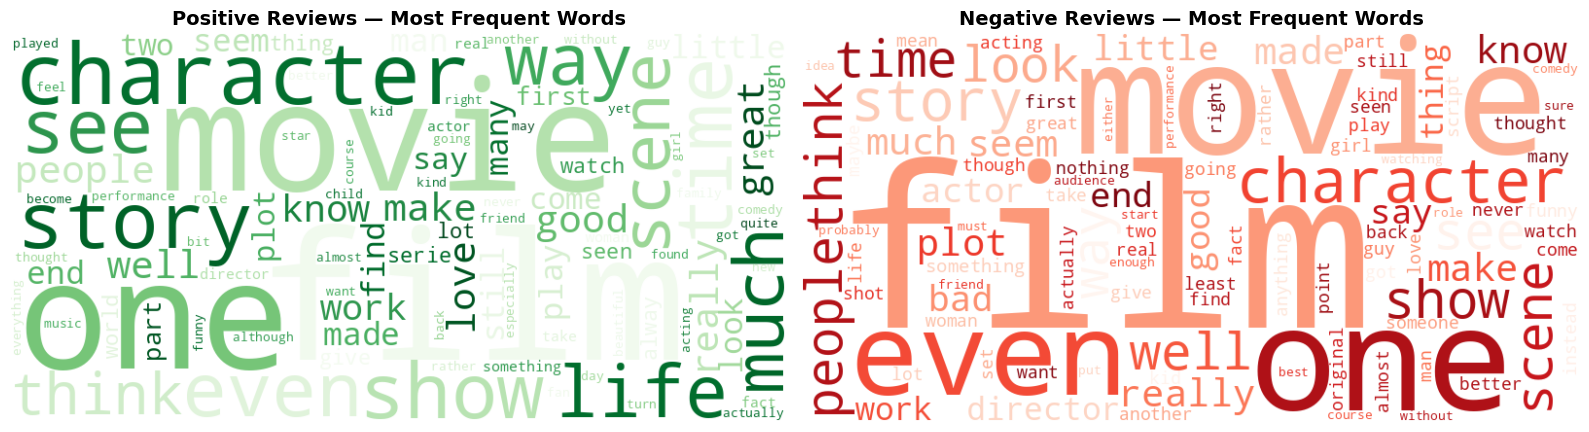

In [30]:
# ── 4.1 Word Cloud ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, label, cmap, title in [
    (axes[0], 1, 'Greens', 'Positive Reviews — Most Frequent Words'),
    (axes[1], 0, 'Reds',   'Negative Reviews — Most Frequent Words')
]:
    text = ' '.join(train_df[train_df['sentiment']==label]['clean_review'])
    wc = WordCloud(width=800, height=400, background_color='white',
                   colormap=cmap, max_words=100).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

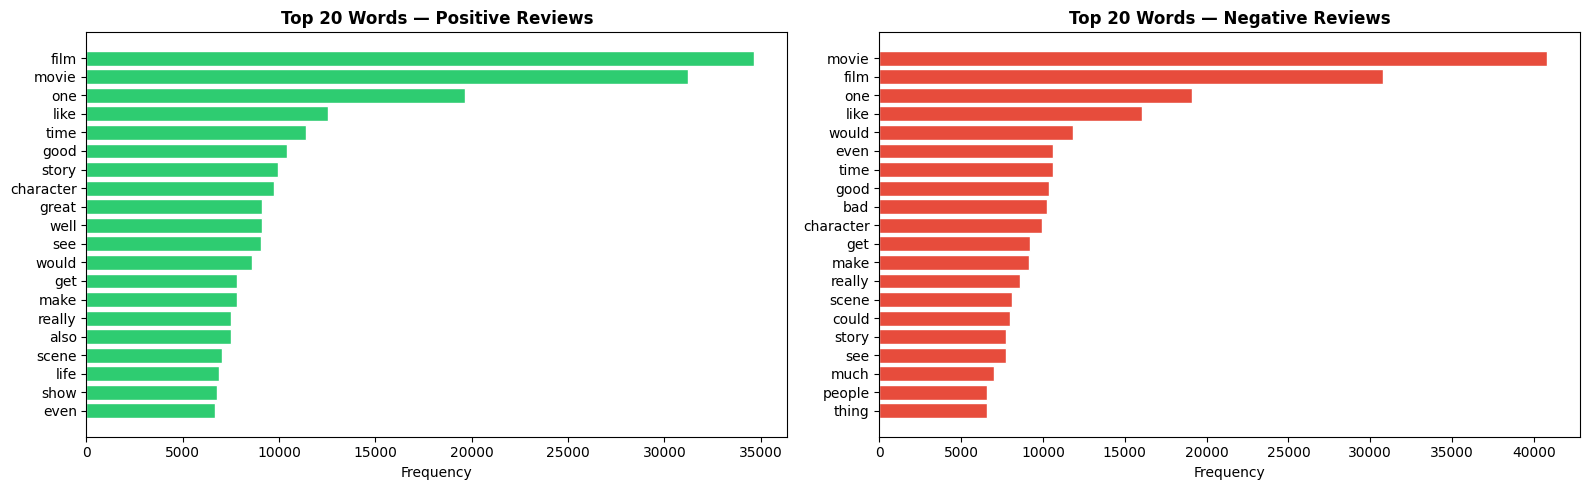

In [31]:
# ── 4.2 Top 20 Words per Class ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, label, color, title in [
    (axes[0], 1, '#2ecc71', 'Top 20 Words — Positive Reviews'),
    (axes[1], 0, '#e74c3c', 'Top 20 Words — Negative Reviews')
]:
    all_words = ' '.join(train_df[train_df['sentiment']==label]['clean_review']).split()
    top_words = Counter(all_words).most_common(20)
    words, counts = zip(*top_words)
    ax.barh(list(reversed(words)), list(reversed(counts)), color=color, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Frequency')
plt.tight_layout()
plt.savefig('top_words.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Tokenization and Sequence Padding

In [32]:
VOCAB_SIZE  = 10000
OOV_TOKEN   = '<OOV>'
MAX_LENGTH  = 150    # Used for LSTM and LSTM+GloVe

print(f'VOCAB_SIZE : {VOCAB_SIZE}')
print(f'MAX_LENGTH : {MAX_LENGTH} words (for LSTM models)')

# Fit tokenizer ONLY on training data to prevent data leakage
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(train_df['clean_review'])
word_index = tokenizer.word_index
print(f'Unique words in corpus : {len(word_index):,}')
print(f'Tokenizer covers top   : {VOCAB_SIZE:,} words')

# Padded sequences for LSTM models (MAX_LENGTH=150)
X_train = pad_sequences(tokenizer.texts_to_sequences(train_df['clean_review']),
                        maxlen=MAX_LENGTH, padding='post', truncating='post')
X_val   = pad_sequences(tokenizer.texts_to_sequences(val_df['clean_review']),
                        maxlen=MAX_LENGTH, padding='post', truncating='post')
X_test  = pad_sequences(tokenizer.texts_to_sequences(test_df['clean_review']),
                        maxlen=MAX_LENGTH, padding='post', truncating='post')

# ── FIXED: Shorter sequences for Simple RNN to prevent vanishing gradient ─────
MAX_LENGTH_RNN = 80   # SimpleRNN cannot carry memory across 150 steps
X_train_rnn = pad_sequences(tokenizer.texts_to_sequences(train_df['clean_review']),
                             maxlen=MAX_LENGTH_RNN, padding='post', truncating='post')
X_val_rnn   = pad_sequences(tokenizer.texts_to_sequences(val_df['clean_review']),
                             maxlen=MAX_LENGTH_RNN, padding='post', truncating='post')
X_test_rnn  = pad_sequences(tokenizer.texts_to_sequences(test_df['clean_review']),
                             maxlen=MAX_LENGTH_RNN, padding='post', truncating='post')

y_train = train_df['sentiment'].values
y_val   = val_df['sentiment'].values
y_test  = test_df['sentiment'].values

print(f'\nX_train (LSTM)     : {X_train.shape}')
print(f'X_train_rnn (RNN)  : {X_train_rnn.shape}')
print(f'X_val              : {X_val.shape}')
print(f'X_test             : {X_test.shape}')

VOCAB_SIZE : 10000
MAX_LENGTH : 150 words (for LSTM models)
Unique words in corpus : 78,307
Tokenizer covers top   : 10,000 words

X_train (LSTM)     : (35000, 150)
X_train_rnn (RNN)  : (35000, 80)
X_val              : (5000, 150)
X_test             : (10000, 150)


## 6. Load GloVe Embeddings

In [33]:
# Load GloVe ONCE — reused for Model 3
GLOVE_DIM = 100
print('Downloading GloVe (glove-wiki-gigaword-100) — ~130MB, takes a few minutes...')
glove_model = api.load('glove-wiki-gigaword-100')
print('GloVe loaded!')

# Build embedding matrix
embedding_matrix = np.zeros((VOCAB_SIZE, GLOVE_DIM))
hits, misses = 0, 0
for word, idx in word_index.items():
    if idx >= VOCAB_SIZE:
        continue
    if word in glove_model:
        embedding_matrix[idx] = glove_model[word]
        hits += 1
    else:
        misses += 1

print(f'\nEmbedding coverage : {hits:,} words ({hits/(hits+misses)*100:.1f}%)')
print(f'Words not in GloVe : {misses:,}')

GloVe loaded!

Embedding coverage : 9,995 words (100.0%)
Words not in GloVe : 4


## 7. Model Building

### Model 1 — Simple RNN with Trainable Embedding (Fixed)

In [35]:
# ── Model 1: Simple RNN (FIXED) ──────────────────────────────────────────────

RNN_EMBEDDING_DIM = 128

rnn_model = Sequential(name='Simple_RNN_Fixed')
rnn_model.add(Embedding(input_dim=VOCAB_SIZE, output_dim=RNN_EMBEDDING_DIM,
                         input_length=MAX_LENGTH_RNN))
rnn_model.add(SimpleRNN(units=128, return_sequences=True))   # No recurrent_dropout
rnn_model.add(SimpleRNN(units=64,  return_sequences=False))  # Stacked = richer features
rnn_model.add(Dense(64, activation='relu'))
rnn_model.add(Dropout(0.5))
rnn_model.add(Dense(1, activation='sigmoid'))

rnn_model.compile(
    optimizer=Adam(learning_rate=0.0005, clipnorm=5.0),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
rnn_model.summary()

Model: "Simple_RNN_Fixed"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Model 2 — LSTM with Trainable Embedding

In [ ]:
# ── Model 2: LSTM ─────────────────────────────────────────────────────────────
EMBEDDING_DIM = 64   # Used for LSTM models only

lstm_model = Sequential(name='LSTM_Model')
lstm_model.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM,
                         input_length=MAX_LENGTH))
lstm_model.add(LSTM(units=128, return_sequences=True,
                    dropout=0.2, recurrent_dropout=0.2))
lstm_model.add(LSTM(units=64, return_sequences=False,
                    dropout=0.2, recurrent_dropout=0.2))
lstm_model.add(Dense(32, activation='relu'))
lstm_model.add(Dropout(0.3))
lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.compile(
    optimizer=Adam(learning_rate=0.001, clipnorm=1.0),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
lstm_model.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Model 3 — LSTM with Pretrained GloVe Word2Vec Embeddings

In [ ]:
# ── Model 3: LSTM + GloVe ─────────────────────────────────────────────────────
lstm_w2v_model = Sequential(name='LSTM_GloVe')
lstm_w2v_model.add(Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=GLOVE_DIM,
    weights=[embedding_matrix],
    input_length=MAX_LENGTH,
    trainable=False          # freeze pretrained weights
))
lstm_w2v_model.add(LSTM(units=128, return_sequences=True,
                        dropout=0.2, recurrent_dropout=0.2))
lstm_w2v_model.add(LSTM(units=64, return_sequences=False,
                        dropout=0.2, recurrent_dropout=0.2))
lstm_w2v_model.add(Dense(32, activation='relu'))
lstm_w2v_model.add(Dropout(0.3))
lstm_w2v_model.add(Dense(1, activation='sigmoid'))

lstm_w2v_model.compile(
    optimizer=Adam(learning_rate=0.001, clipnorm=1.0),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
lstm_w2v_model.summary()

Model: "LSTM_GloVe"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,000,000 (3.81 MB)

## 8. Model Training

In [ ]:
EPOCHS     = 15
BATCH_SIZE = 256    # large batch = fast epochs on GPU

def get_callbacks(patience=4):
    return [
        EarlyStopping(
            monitor='val_accuracy',
            patience=patience,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1
        )
    ]

In [42]:
# ── Train Model 1: Simple RNN ─────────────────────────────────────────────────
print('=' * 55)
print('  Training Model 1: Simple RNN (Fixed)')
print('=' * 55)
t0 = time.time()
history_rnn = rnn_model.fit(
    X_train_rnn, y_train,           # Uses shorter 80-token sequences
    validation_data=(X_val_rnn, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(patience=2),
    verbose=1
)
rnn_time = time.time() - t0
print(f'\nSimple RNN training time: {rnn_time/60:.1f} minutes')

  Training Model 1: Simple RNN (Fixed)
Epoch 1/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 14s 43ms/step - accuracy: 0.5008 - loss: 0.6996 - val_accuracy: 0.4892 - val_loss: 0.6938 - learning_rate: 5.0000e-04
Epoch 2/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.5039 - loss: 0.6935 - val_accuracy: 0.5108 - val_loss: 0.6931 - learning_rate: 5.0000e-04
Epoch 3/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.5050 - loss: 0.6931 - val_accuracy: 0.5134 - val_loss: 0.6927 - learning_rate: 5.0000e-04
Epoch 4/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.5165 - loss: 0.6925 - val_accuracy: 0.5340 - val_loss: 0.6911 - learning_rate: 5.0000e-04
Epoch 5/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.7303 - loss: 0.5314 - val_accuracy: 0.8414 - val_loss: 0.3878 - learning_rate: 5.0000e-04
Epoch 6/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8906 - loss: 0.2902 - val_accuracy: 0.8304 - val_loss: 0.4331 - learning_rate: 5.0000e-04
Epoch 7/15
135/137

In [ ]:
# ── Train Model 2: LSTM ───────────────────────────────────────────────────────
print('=' * 55)
print('  Training Model 2: LSTM')
print('=' * 55)
t0 = time.time()
history_lstm = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(patience=4),
    verbose=1
)
lstm_time = time.time() - t0
print(f'\nLSTM training time: {lstm_time/60:.1f} minutes')

  Training Model 2: LSTM
Epoch 1/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 160s 1s/step - accuracy: 0.5169 - loss: 0.6903 - val_accuracy: 0.5560 - val_loss: 0.6805 - learning_rate: 0.0010
Epoch 2/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 197s 1s/step - accuracy: 0.6647 - loss: 0.6195 - val_accuracy: 0.7388 - val_loss: 0.5806 - learning_rate: 0.0010
Epoch 3/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 200s 1s/step - accuracy: 0.7688 - loss: 0.5446 - val_accuracy: 0.7906 - val_loss: 0.5012 - learning_rate: 0.0010
Epoch 4/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 160s 1s/step - accuracy: 0.7917 - loss: 0.5112 - val_accuracy: 0.8090 - val_loss: 0.4775 - learning_rate: 0.0010
Epoch 5/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 150s 1s/step - accuracy: 0.8183 - loss: 0.4683 - val_accuracy: 0.8174 - val_loss: 0.4677 - learning_rate: 0.0010
Epoch 6/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 201s 1s/step - accuracy: 0.8289 - loss: 0.4398 - val_accuracy: 0.8170 - val_loss: 0.4491 - learning_rate: 0.0010
Epoch 7/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - ac

In [ ]:
# ── Train Model 3: LSTM + GloVe ───────────────────────────────────────────────
print('=' * 55)
print('  Training Model 3: LSTM + GloVe Word2Vec')
print('=' * 55)
t0 = time.time()
history_w2v = lstm_w2v_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(patience=4),
    verbose=1
)
w2v_time = time.time() - t0
print(f'\nLSTM + GloVe training time: {w2v_time/60:.1f} minutes')

## 9. Training Visualization

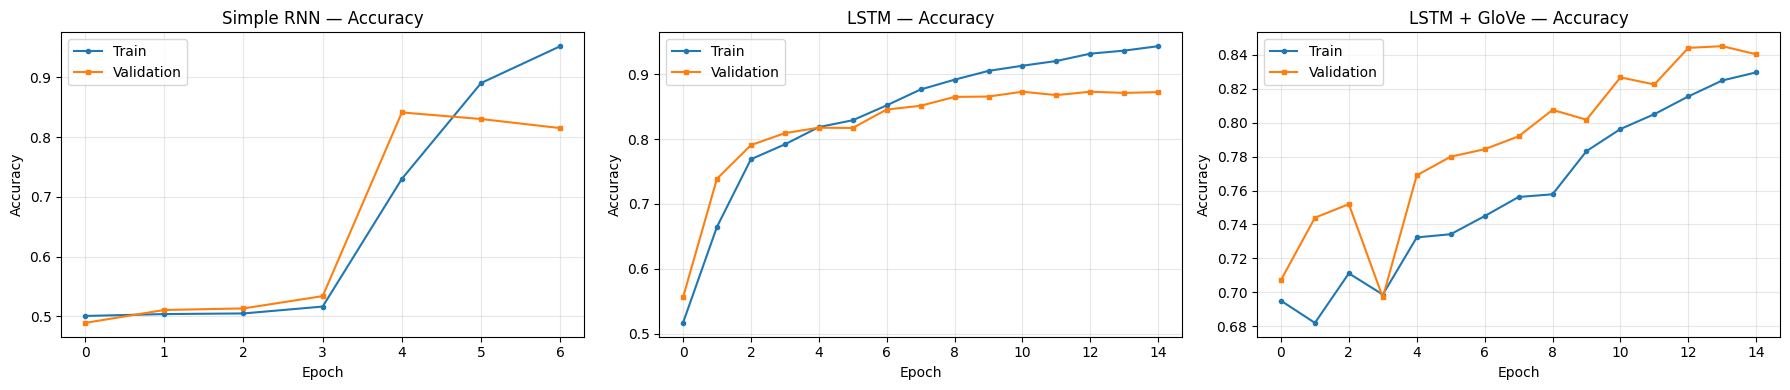

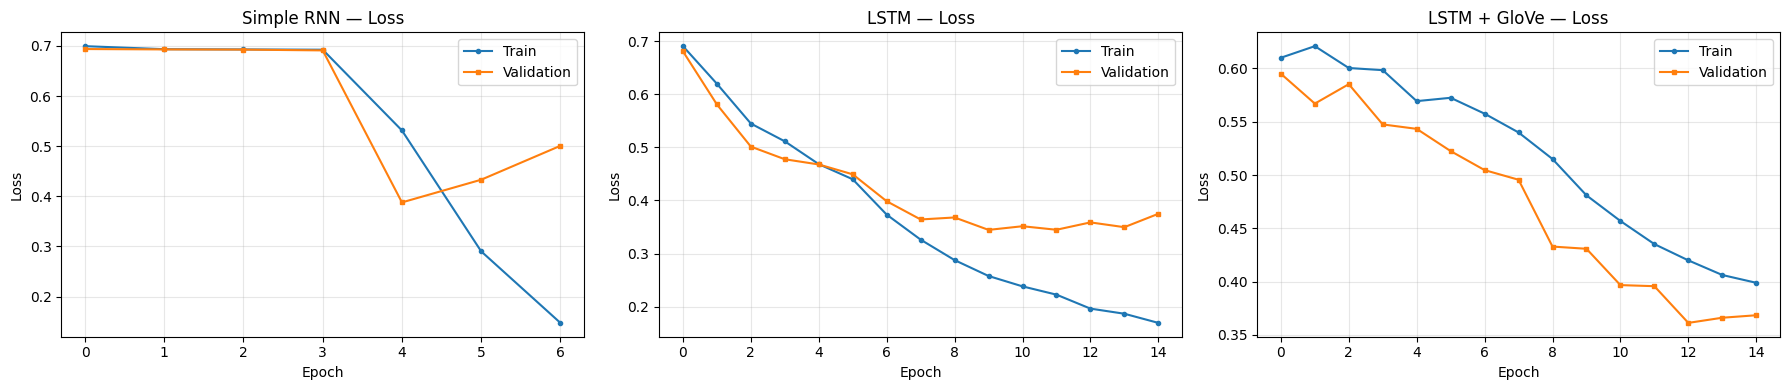

In [43]:
ALL_HISTORIES = [history_rnn, history_lstm, history_w2v]
ALL_NAMES     = ['Simple RNN', 'LSTM', 'LSTM + GloVe']

def plot_history(histories, names, metric='accuracy'):
    fig, axes = plt.subplots(1, len(histories), figsize=(6*len(histories), 4))
    for ax, hist, name in zip(axes, histories, names):
        ax.plot(hist.history[metric],          label='Train',      marker='o', markersize=3)
        ax.plot(hist.history[f'val_{metric}'], label='Validation', marker='s', markersize=3)
        ax.set_title(f'{name} — {metric.capitalize()}')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(metric.capitalize())
        ax.legend()
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'training_{metric}.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_history(ALL_HISTORIES, ALL_NAMES, metric='accuracy')
plot_history(ALL_HISTORIES, ALL_NAMES, metric='loss')

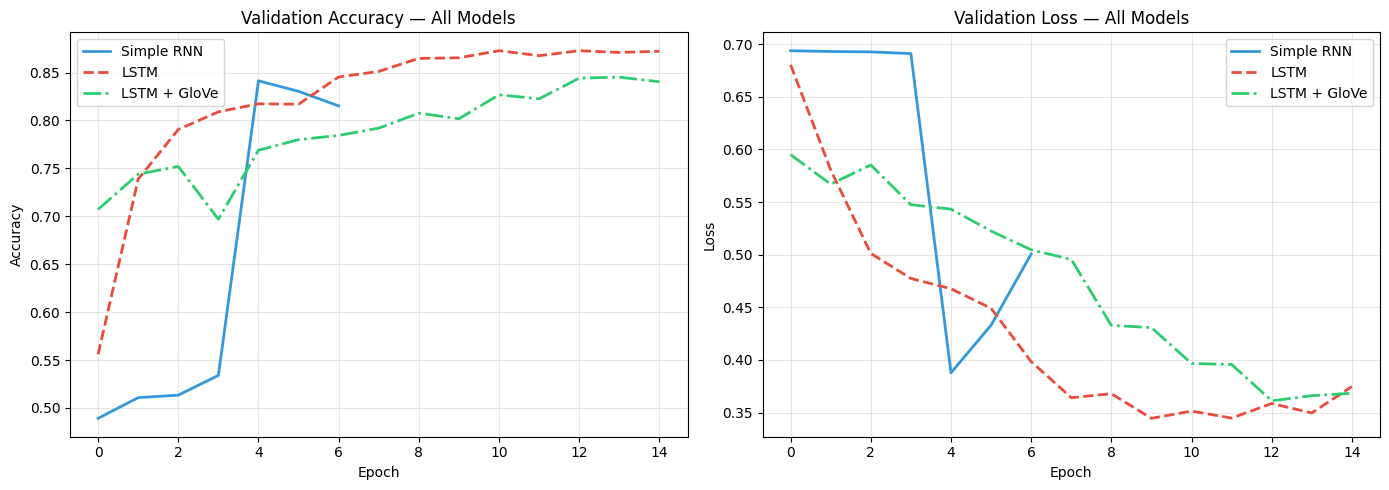

In [44]:
# ── Combined validation comparison ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#3498db', '#e74c3c', '#2ecc71']
styles = ['-', '--', '-.']

for ax, metric in zip(axes, ['accuracy', 'loss']):
    for hist, name, color, ls in zip(ALL_HISTORIES, ALL_NAMES, colors, styles):
        ax.plot(hist.history[f'val_{metric}'], label=name,
                color=color, linestyle=ls, linewidth=2)
    ax.set_title(f'Validation {metric.capitalize()} — All Models')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(metric.capitalize())
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Model Evaluation on Test Set


  Model         : Simple RNN
  Test Accuracy : 83.94%
              precision    recall  f1-score   support

    Negative       0.86      0.81      0.83      4961
    Positive       0.82      0.87      0.85      5039

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000



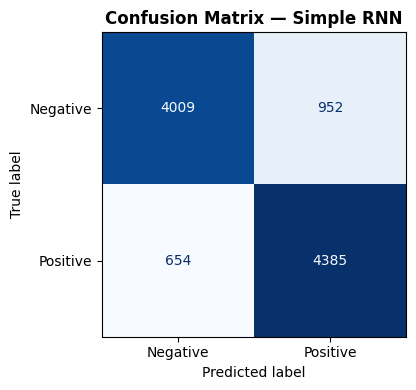


  Model         : LSTM
  Test Accuracy : 86.41%
              precision    recall  f1-score   support

    Negative       0.88      0.84      0.86      4961
    Positive       0.85      0.89      0.87      5039

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



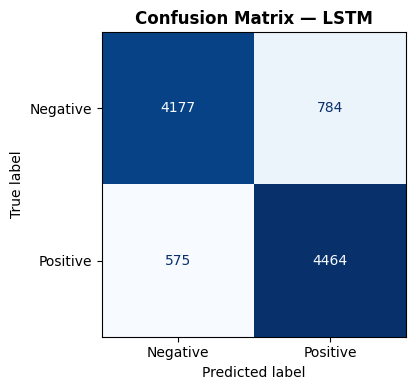


  Model         : LSTM + GloVe
  Test Accuracy : 83.61%
              precision    recall  f1-score   support

    Negative       0.89      0.76      0.82      4961
    Positive       0.80      0.91      0.85      5039

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000



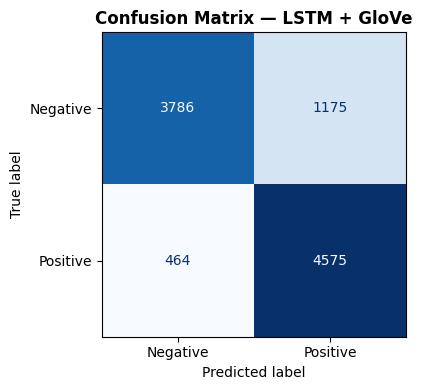

In [45]:
def evaluate_model(model, X_test, y_test, name):
    y_pred_prob = model.predict(X_test, verbose=0)
    y_pred      = (y_pred_prob > 0.5).astype(int).flatten()
    acc = accuracy_score(y_test, y_pred)

    print(f"\n{'='*55}")
    print(f'  Model         : {name}')
    print(f'  Test Accuracy : {acc*100:.2f}%')
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred,
                                target_names=['Negative','Positive']))

    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Negative','Positive'])
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Confusion Matrix — {name}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'cm_{name.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

    return acc, y_pred

# NOTE: RNN uses X_test_rnn (80 tokens), LSTM models use X_test (150 tokens)
acc_rnn,  pred_rnn  = evaluate_model(rnn_model,      X_test_rnn, y_test, 'Simple RNN')
acc_lstm, pred_lstm = evaluate_model(lstm_model,      X_test,     y_test, 'LSTM')
acc_w2v,  pred_w2v  = evaluate_model(lstm_w2v_model,  X_test,     y_test, 'LSTM + GloVe')

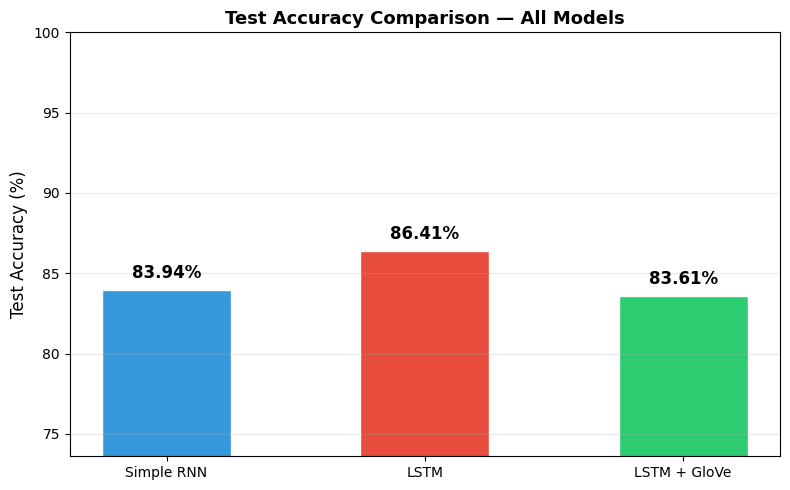

In [46]:
# ── Accuracy Bar Chart ────────────────────────────────────────────────────────
model_names = ['Simple RNN', 'LSTM', 'LSTM + GloVe']
accuracies  = [acc_rnn, acc_lstm, acc_w2v]
bar_colors  = ['#3498db', '#e74c3c', '#2ecc71']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(model_names, [a*100 for a in accuracies],
              color=bar_colors, edgecolor='white', width=0.5)
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{acc*100:.2f}%', ha='center', va='bottom',
            fontweight='bold', fontsize=12)

y_min = max(0, min(accuracies)*100 - 10)
ax.set_ylim(y_min, 100)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Test Accuracy Comparison — All Models', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Results Summary Table

In [47]:
training_times = {
    'Simple RNN'  : f'{rnn_time/60:.1f} min',
    'LSTM'        : f'{lstm_time/60:.1f} min',
    'LSTM + GloVe': f'{w2v_time/60:.1f} min',
}

results = []
for name, preds in [('Simple RNN', pred_rnn),
                    ('LSTM',        pred_lstm),
                    ('LSTM + GloVe', pred_w2v)]:
    results.append({
        'Model'        : name,
        'Accuracy'     : f"{accuracy_score(y_test, preds)*100:.2f}%",
        'Precision'    : f"{precision_score(y_test, preds)*100:.2f}%",
        'Recall'       : f"{recall_score(y_test, preds)*100:.2f}%",
        'F1-Score'     : f"{f1_score(y_test, preds)*100:.2f}%",
        'Training Time': training_times[name],
    })

results_df = pd.DataFrame(results)
print('\n' + '='*75)
print('  FINAL RESULTS SUMMARY')
print('='*75)
print(results_df.to_string(index=False))
print('='*75)


  FINAL RESULTS SUMMARY
       Model Accuracy Precision Recall F1-Score Training Time
  Simple RNN   83.94%    82.16% 87.02%   84.52%       0.5 min
        LSTM   86.41%    85.06% 88.59%   86.79%      43.5 min
LSTM + GloVe   83.61%    79.57% 90.79%   84.81%      36.4 min


## 12. Error Analysis

In [48]:
# Use best model for error analysis
best_acc   = max(acc_rnn, acc_lstm, acc_w2v)
best_name  = ['Simple RNN','LSTM','LSTM + GloVe'][
              [acc_rnn, acc_lstm, acc_w2v].index(best_acc)]
best_preds = {'Simple RNN': pred_rnn, 'LSTM': pred_lstm,
              'LSTM + GloVe': pred_w2v}[best_name]

print(f'Best model : {best_name} ({best_acc*100:.2f}%)')

test_copy = test_df.copy().reset_index(drop=True)
test_copy['predicted'] = best_preds
test_copy['correct']   = test_copy['sentiment'] == test_copy['predicted']
misclassified = test_copy[~test_copy['correct']]

false_pos = misclassified[misclassified['sentiment'] == 0]
false_neg = misclassified[misclassified['sentiment'] == 1]

print(f'Total misclassified : {len(misclassified):,} / {len(test_copy):,}')
print(f'Error rate          : {len(misclassified)/len(test_copy)*100:.2f}%')
print(f'False Positives     : {len(false_pos):,} (negative predicted as positive)')
print(f'False Negatives     : {len(false_neg):,} (positive predicted as negative)')

Best model : LSTM (86.41%)
Total misclassified : 1,359 / 10,000
Error rate          : 13.59%
False Positives     : 784 (negative predicted as positive)
False Negatives     : 575 (positive predicted as negative)


In [49]:
label_map = {0: 'Negative', 1: 'Positive'}
reasons = [
    'Sarcasm or irony — the review uses praise-like words to express disappointment. '
    'The model cannot detect tone or context shift.',
    'Mixed sentiment — the review praises some aspects but criticises others. '
    'The model latches onto the dominant word pattern and misclassifies the overall sentiment.',
    'Ambiguous or hedging language — words like "not bad", "could be worse", or "surprisingly decent" '
    'are difficult for the model after stopword removal weakens negation context.'
]

print('=' * 70)
print(f'  Sample Misclassified Reviews — {best_name}')
print('=' * 70)

samples = misclassified.sample(3, random_state=42).reset_index(drop=True)
for i, row in samples.iterrows():
    print(f'\n--- Example {i+1} ---')
    print(f"Review (first 350 chars):\n{row['review'][:350]}...")
    print(f"True Label  : {label_map[row['sentiment']]}")
    print(f"Predicted   : {label_map[row['predicted']]}")
    print(f"Reason      : {reasons[i]}")

print('\n' + '=' * 70)
print('Suggested Improvements:')
print('  1. Use attention mechanisms or Transformer (BERT) for better context.')
print('  2. Use 300-dim GloVe or fastText for richer word representations.')
print('  3. Keep negation words (not, never) — currently removed as stopwords.')
print('  4. Apply data augmentation or fine-tune on domain-specific reviews.')

  Sample Misclassified Reviews — LSTM

--- Example 1 ---
Review (first 350 chars):
I watched DVD 1 only. The program proper may have 10 minutes of good information; otherwise it's snotty putdowns of religious people. It's as if director Brian Flemming only recently discovered both atheism and sarcasm, and feels with these tools he can easily bludgeon his opposition.<br /><br />Also, Flemming wanders extensively into his own perso...
True Label  : Negative
Predicted   : Positive
Reason      : Sarcasm or irony — the review uses praise-like words to express disappointment. The model cannot detect tone or context shift.

--- Example 2 ---
Review (first 350 chars):
The most amazing, spiritually uplifting movie about the restoration of the gospel. Far better than any other film, or movie made about the restoration thus far. If you haven't seen it, hop on a plane to Salt Lake and see it now. You won't regret it! You truly get a sense of what the first saints had to struggle through, putting c

## 13. GUI for Real-Time Prediction (Gradio)

In [50]:
import gradio as gr

def predict_sentiment(review_text):
    if not review_text.strip():
        return 'Please enter a movie review.'
    cleaned  = clean_text(review_text)

    # RNN uses shorter sequence (80 tokens)
    seq_rnn  = pad_sequences(tokenizer.texts_to_sequences([cleaned]),
                              maxlen=MAX_LENGTH_RNN, padding='post', truncating='post')
    # LSTM models use 150 tokens
    seq_lstm = pad_sequences(tokenizer.texts_to_sequences([cleaned]),
                              maxlen=MAX_LENGTH, padding='post', truncating='post')

    p_rnn  = rnn_model.predict(seq_rnn,       verbose=0)[0][0]
    p_lstm = lstm_model.predict(seq_lstm,     verbose=0)[0][0]
    p_w2v  = lstm_w2v_model.predict(seq_lstm, verbose=0)[0][0]

    def fmt(name, prob):
        label = '✅ Positive' if prob >= 0.5 else '❌ Negative'
        conf  = max(prob, 1-prob) * 100
        return f'{name:<20}: {label}  (confidence: {conf:.1f}%)'

    return '\n'.join([
        fmt('Simple RNN',   p_rnn),
        fmt('LSTM',         p_lstm),
        fmt('LSTM + GloVe', p_w2v),
    ])

interface = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(lines=5,
                      placeholder='Type or paste a movie review here...',
                      label='Movie Review'),
    outputs=gr.Textbox(label='Predicted Sentiment — All 3 Models'),
    title='🎬 Movie Review Sentiment Analyser',
    description='Compares Simple RNN · LSTM · LSTM + GloVe trained on 35,000 IMDb reviews.',
    examples=[
        ['This movie was absolutely fantastic! The acting was superb and the '
         'story kept me completely hooked from start to finish.'],
        ['Terrible film. A complete waste of two hours. Poor acting, '
         'a boring plot, and awful direction. Avoid at all costs.'],
        ['It was okay I guess. Some parts were interesting but overall '
         'it felt a bit flat and predictable.']
    ]
)
interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://10051501f5c0f49da1.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
